In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import kagglehub
import glob

# Dataset Loading

In [3]:
path = kagglehub.dataset_download("kmljts/reside-6k")

100%|██████████| 1.48G/1.48G [00:39<00:00, 40.2MB/s]

Extracting files...


In [4]:
def load_pair(img_path, ground_truth_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [256, 256])

    gt = tf.io.read_file(ground_truth_path)
    gt = tf.image.decode_jpeg(gt, channels=3)
    gt = tf.image.resize(gt, [256, 256])

    return img, gt

def make_dataset(split, path):
    img_paths  = sorted(glob.glob(f"{path}/RESIDE-6K/{split}/hazy/*.jpg"))
    gt_paths = sorted(glob.glob(f"{path}/RESIDE-6K/{split}/GT/*.jpg"))

    ds = tf.data.Dataset.from_tensor_slices((img_paths, gt_paths))
    ds = ds.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [5]:
def preprocess(hazy, clean):
    hazy = tf.cast(hazy, tf.float32) / 255.0
    clean = tf.cast(clean, tf.float32) / 255.0
    return hazy, clean

In [6]:
def augment(hazy, clean):
    combined = tf.concat([hazy, clean], axis=-1)

    combined = tf.image.random_flip_left_right(combined)
    combined = tf.image.random_flip_up_down(combined)

    crop_size = tf.random.uniform([], minval=200, maxval=256, dtype=tf.int32)
    combined = tf.image.random_crop(combined, size=[crop_size, crop_size, 6])
    combined = tf.image.resize(combined, [256, 256])

    hazy = combined[..., :3]
    clean = combined[..., 3:]

    return hazy, clean

In [7]:
print(path)

/root/.cache/kagglehub/datasets/kmljts/reside-6k/versions/1


In [8]:
train_raw = make_dataset("train", path)
test_raw = make_dataset("test", path)

train_ds = train_raw.take(int(len(train_raw) * 0.85)).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).map(augment, num_parallel_calls=tf.data.AUTOTUNE).batch(32).cache().prefetch(tf.data.AUTOTUNE)

val_ds = train_raw.skip(int(len(train_raw) * 0.85)).take(int(len(train_raw) * 0.15)).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(32).cache().prefetch(tf.data.AUTOTUNE)

test_ds = test_raw.batch(32).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# God what have I done

2026-05-22 20:48:45.059302: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18330 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:81:00.0, compute capability: 8.6


# Model Definition

In [25]:
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def ssim_metric(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

In [26]:
inputs = layers.Input(shape=(256, 256, 3))
x = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
sk1 = x
x = layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
sk2 = x
x = layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
sk3 = x
x = layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
x = layers.Conv2D(512, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(512, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(size=(2, 2))(x)
x = layers.Concatenate()([x, sk3])
x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(size=(2, 2))(x)
x = layers.Concatenate()([x, sk2])
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(size=(2, 2))(x)
x = layers.Concatenate()([x, sk1])
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
outputs = layers.Conv2D(3, 1, activation="sigmoid", padding="same")(x)

In [27]:
model = keras.Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse", metrics=[psnr_metric, ssim_metric])

In [28]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 128, 128,  │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_17[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_4[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_19[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_5[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │  2,359,808 │ conv2d_21[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 64, 64,    │          0 │ conv2d_22[0][0]   │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 768)              │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │  1,769,728 │ concatenate_3[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_23[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 128, 128,  │          0 │ conv2d_24[0][0] 

 Total params: 7,783,043 (29.69 MB)

 Trainable params: 7,783,043 (29.69 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [13]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    start_from_epoch=10
)

In [14]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [15]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="model_{epoch:02d}.keras",
    save_freq="epoch",
    verbose=1
)

In [16]:
model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[early_stopping, reduce_lr, checkpoint])

Epoch 1/100


2026-05-22 20:48:48.757088: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8905
2026-05-22 20:48:48.881597: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-22 20:48:52.528849: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-22 20:48:53.863639: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x75a4314dfb70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-22 20:48:53.863682: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A4500, Compute Capability 8.6
2026-05-22 20:48:53.868659: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-22 20:48:53.980384: I ./tensorflow/compiler/jit/device_compiler.h:

160/160 [==============================] - ETA: 0s - loss: 0.0346 - psnr_metric: 15.9908 - ssim_metric: 0.6039
Epoch 1: saving model to model_01.keras
160/160 [==============================] - 118s 607ms/step - loss: 0.0346 - psnr_metric: 15.9908 - ssim_metric: 0.6039 - val_loss: 0.0348 - val_psnr_metric: 15.1503 - val_ssim_metric: 0.6027 - lr: 0.0010
Epoch 2/100
160/160 [==============================] - ETA: 0s - loss: 0.0183 - psnr_metric: 19.1690 - ssim_metric: 0.7439
Epoch 2: saving model to model_02.keras
160/160 [==============================] - 74s 465ms/step - loss: 0.0183 - psnr_metric: 19.1690 - ssim_metric: 0.7439 - val_loss: 0.0221 - val_psnr_metric: 17.2238 - val_ssim_metric: 0.6968 - lr: 0.0010
Epoch 3/100
160/160 [==============================] - ETA: 0s - loss: 0.0164 - psnr_metric: 19.7089 - ssim_metric: 0.7810
Epoch 3: saving model to model_03.keras
160/160 [==============================] - 74s 466ms/step - loss: 0.0164 - psnr_metric: 19.7089 - ssim_metric: 0.781

In [17]:
def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.8 * mse + 0.2 * ssim

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00025),
    loss=combined_loss,
    metrics=[psnr_metric, ssim_metric]
)

In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[early_stopping, reduce_lr, checkpoint])

Epoch 1/100
160/160 [==============================] - ETA: 0s - loss: 0.0226 - psnr_metric: 24.7935 - ssim_metric: 0.9065
Epoch 1: saving model to model_01.keras
160/160 [==============================] - 94s 510ms/step - loss: 0.0226 - psnr_metric: 24.7935 - ssim_metric: 0.9065 - val_loss: 0.0269 - val_psnr_metric: 23.6063 - val_ssim_metric: 0.8901 - lr: 2.5000e-04
Epoch 2/100
160/160 [==============================] - ETA: 0s - loss: 0.0212 - psnr_metric: 24.9998 - ssim_metric: 0.9124
Epoch 2: saving model to model_02.keras
160/160 [==============================] - 77s 485ms/step - loss: 0.0212 - psnr_metric: 24.9998 - ssim_metric: 0.9124 - val_loss: 0.0261 - val_psnr_metric: 23.7581 - val_ssim_metric: 0.8936 - lr: 2.5000e-04
Epoch 3/100
160/160 [==============================] - ETA: 0s - loss: 0.0202 - psnr_metric: 25.1629 - ssim_metric: 0.9162
Epoch 3: saving model to model_03.keras
160/160 [==============================] - 78s 489ms/step - loss: 0.0202 - psnr_metric: 25.1629 -

# Testing

In [29]:
model.load_weights("models/model_15.keras")

In [31]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step


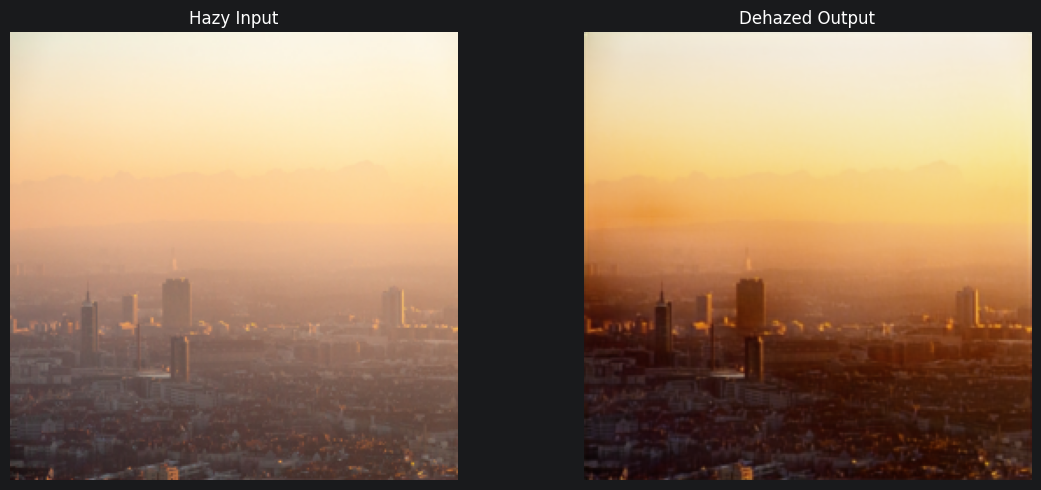

In [32]:
img = Image.open('data/fog-or-smog-detection-dataset/foggy/Fog1 (6).jpg').convert('RGB')
img = img.resize((256, 256))
img = np.array(img, dtype=np.float32) / 255.0
img = np.expand_dims(img, axis=0)

output = model.predict(img)

result = (output[0] * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img[0])
axes[0].set_title('Hazy Input')
axes[0].axis('off')

axes[1].imshow(output[0])
axes[1].set_title('Dehazed Output')
axes[1].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step


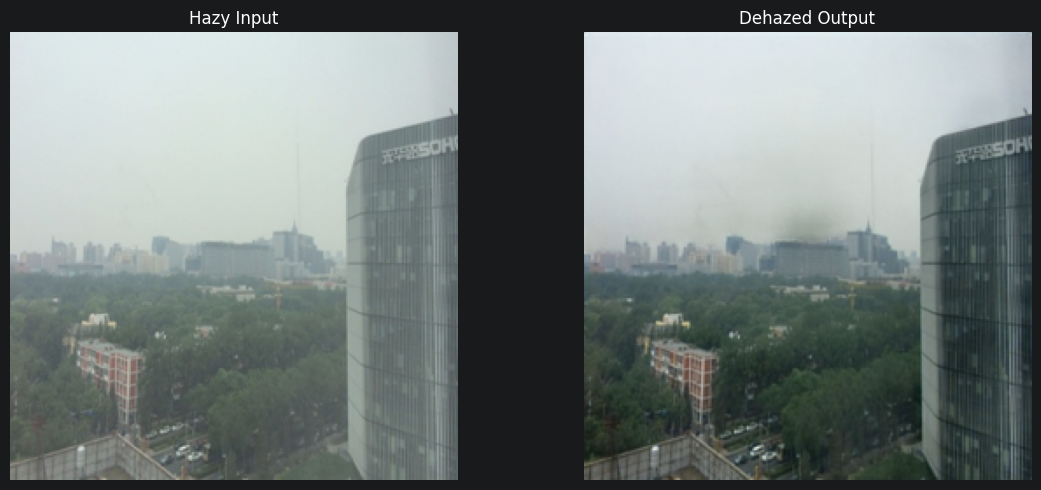

In [33]:
img = Image.open('1009.jpg').convert('RGB') # from the RESIDE dataset
img = img.resize((256, 256))
img = np.array(img, dtype=np.float32) / 255.0
img = np.expand_dims(img, axis=0)

output = model.predict(img)

result = (output[0] * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img[0])
axes[0].set_title('Hazy Input')
axes[0].axis('off')

axes[1].imshow(output[0])
axes[1].set_title('Dehazed Output')
axes[1].axis('off')

plt.tight_layout()
plt.show()